# Deep Learning Assignment 1


- Data is loaded from a local `data/` folder.
- Figures are saved into an `outputs/` folder with informative filenames.
- Cells are ordered so dependencies are explicit and minimal.

In [1]:
%matplotlib inline

from pathlib import Path
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import torch
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_samples

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Resolve the working directory for this notebook and find the local data folder.
notebook_dir = Path.cwd()
if not (notebook_dir / "data").exists() and (notebook_dir / "deep_learning_ass1" / "data").exists():
    notebook_dir = notebook_dir / "deep_learning_ass1"

DATA_ROOT = notebook_dir / "data"
OUTPUTS_DIR = notebook_dir / "outputs"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

print("Notebook directory:", notebook_dir)
print("Data root:", DATA_ROOT)
print("Outputs directory:", OUTPUTS_DIR)

if not DATA_ROOT.exists():
    raise FileNotFoundError(f"Expected data directory not found: {DATA_ROOT}")

if not (DATA_ROOT / "cifar-10-batches-py").exists():
    raise FileNotFoundError(f"Expected CIFAR-10 batch folder not found in {DATA_ROOT}")

Using device: cpu
Notebook directory: /home/raveco/deep_learning_ass1
Data root: /home/raveco/deep_learning_ass1/data
Outputs directory: /home/raveco/deep_learning_ass1/outputs


In [2]:
def get_train_val_test_data(validation_size=5000,
                            train_transforms=transforms.ToTensor(),
                            test_transforms=transforms.ToTensor()):
    """
    Load the CIFAR10 dataset and split it into training, validation, and test sets.

    Parameters:
        validation_size (int): Number of samples to use for the validation set.
        train_transforms: Transformations to be applied to the training data.
        test_transforms: Transformations to be applied to the validation and test data.
    """

    # load the training set twice:
    # one copy with train transforms, one copy with test/validation transforms
    full_train_dataset = datasets.CIFAR10(
        root=str(DATA_ROOT),
        train=True,
        download=False,
        transform=train_transforms
    )

    full_val_dataset = datasets.CIFAR10(
        root=str(DATA_ROOT),
        train=True,
        download=False,
        transform=test_transforms
    )

    test_dataset = datasets.CIFAR10(
        root=str(DATA_ROOT),
        train=False,
        download=False,
        transform=test_transforms
    )

    total_train_size = len(full_train_dataset)
    train_size = total_train_size - validation_size

    indices = torch.randperm(total_train_size).tolist()

    train_indices = indices[:train_size]
    val_indices = indices[train_size:]

    train_dataset = Subset(full_train_dataset, train_indices)
    val_dataset = Subset(full_val_dataset, val_indices)

    return train_dataset, val_dataset, test_dataset

In [3]:
train_dataset, val_dataset, test_dataset = get_train_val_test_data()
print("Loaded datasets:")
print("  Train images:", len(train_dataset))
print("  Validation images:", len(val_dataset))
print("  Test images:", len(test_dataset))

/home/raveco/.conda/envs/neuro_dl/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Loaded datasets:
  Train images: 45000
  Validation images: 5000
  Test images: 10000


In [4]:
def save_figure(fig, filename):
    """Save a matplotlib figure to the outputs directory."""
    output_path = OUTPUTS_DIR / filename
    fig.savefig(output_path, bbox_inches="tight")
    print(f"Saved figure: {output_path}")
    return output_path

def show_images(dataset, num_images=5, title=""): #shows images from the dataset
    """Display sample images from the dataset."""
    label_names = dataset.dataset.classes if hasattr(dataset, "dataset") else dataset.classes

    fig, axes = plt.subplots(1, num_images, figsize=(10, 3))
    fig.suptitle(title)

    for i in range(num_images):
        image, label = dataset[i]
        image = image.permute(1, 2, 0).numpy()

        ax = axes[i] if num_images > 1 else axes
        ax.imshow(image)
        ax.set_title(label_names[label])
        ax.axis("off")

    fig.tight_layout()
    return fig

Saved figure: /home/raveco/deep_learning_ass1/outputs/train_samples.png


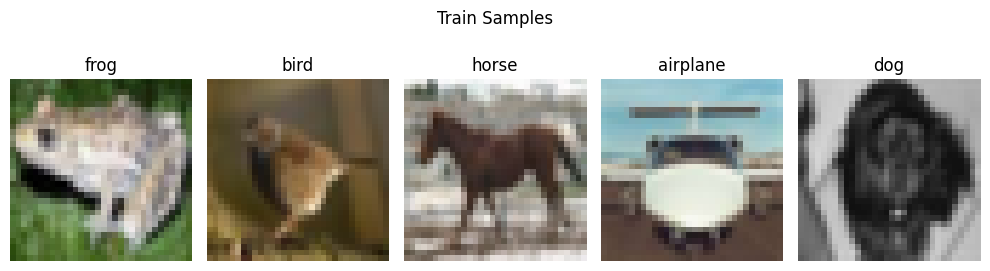

Saved figure: /home/raveco/deep_learning_ass1/outputs/validation_samples.png


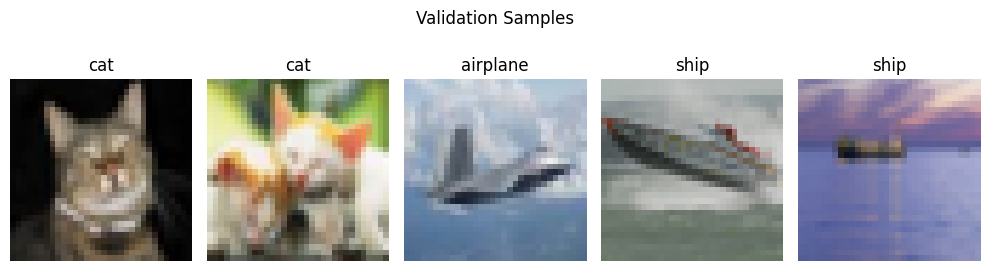

Saved figure: /home/raveco/deep_learning_ass1/outputs/test_samples.png


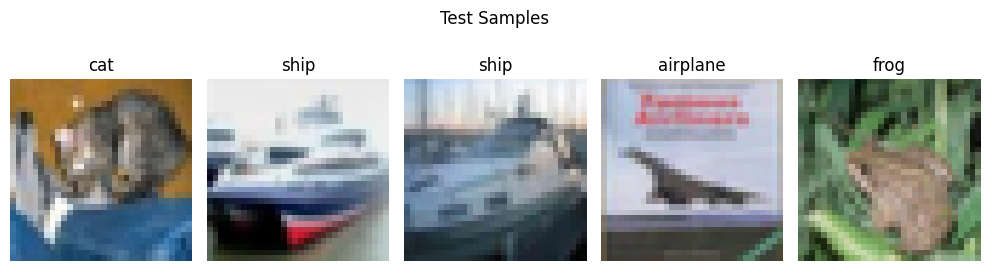

In [5]:
fig = show_images(train_dataset, 5, title="Train Samples")
save_figure(fig, "train_samples.png")
plt.show()

fig = show_images(val_dataset, 5, title="Validation Samples")
save_figure(fig, "validation_samples.png")
plt.show()

fig = show_images(test_dataset, 5, title="Test Samples")
save_figure(fig, "test_samples.png")
plt.show()

Image shape (C, H, W): torch.Size([3, 32, 32])
Label: 3

Channel-wise stats:
Red channel -> min: 0.1804, max: 0.9608, mean: 0.5709
Green channel -> min: 0.1137, max: 0.9529, mean: 0.5513
Blue channel -> min: 0.0784, max: 0.9529, mean: 0.4909
Saved figure: /home/raveco/deep_learning_ass1/outputs/debug_rgb_channels.png


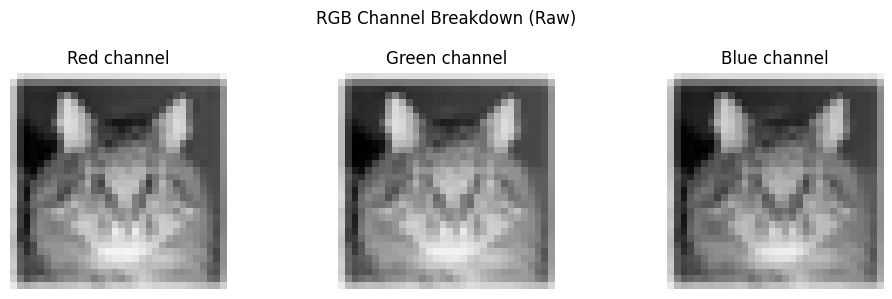

Final image array shape (H, W, C): (32, 32, 3)
Value range: 0.078431375 to 0.9607843
Saved figure: /home/raveco/deep_learning_ass1/outputs/debug_rgb_overlay.png


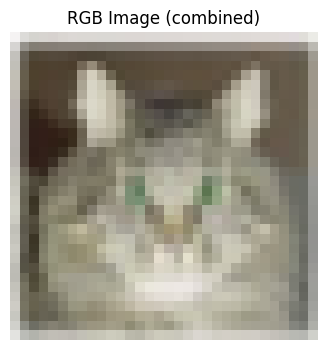

In [6]:
# ===================== DEBUG: IMAGE RGB CHECK =====================

def debug_image_rgb(dataset):
    """Debug: show individual RGB channels and statistics."""
    image, label = dataset[0]  # take first image

    print("Image shape (C, H, W):", image.shape)
    print("Label:", label)

    print("\nChannel-wise stats:")
    for i, color in enumerate(["Red", "Green", "Blue"]):
        print(f"{color} channel -> min: {image[i].min():.4f}, max: {image[i].max():.4f}, mean: {image[i].mean():.4f}")

    # show raw channels
    fig, axs = plt.subplots(1, 3, figsize=(10, 3))
    for i, color in enumerate(["Red", "Green", "Blue"]):
        axs[i].imshow(image[i], cmap="gray")
        axs[i].set_title(f"{color} channel")
        axs[i].axis("off")

    fig.suptitle("RGB Channel Breakdown (Raw)")
    fig.tight_layout()
    return fig


def debug_rgb_overlay(dataset):
    """Debug: show RGB image overlay."""
    image, _ = dataset[0]

    # convert CHW → HWC for display
    img = image.permute(1, 2, 0).numpy()

    fig = plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title("RGB Image (combined)")
    plt.axis("off")

    print("Final image array shape (H, W, C):", img.shape)
    print("Value range:", img.min(), "to", img.max())
    
    return fig


# run debug
train_dataset, val_dataset, test_dataset = get_train_val_test_data()
fig_rgb = debug_image_rgb(train_dataset)
save_figure(fig_rgb, "debug_rgb_channels.png")
plt.show()

fig_overlay = debug_rgb_overlay(train_dataset)
save_figure(fig_overlay, "debug_rgb_overlay.png")
plt.show()

# ================================================================

Saved figure: /home/raveco/deep_learning_ass1/outputs/class_distribution_train_val_test.png


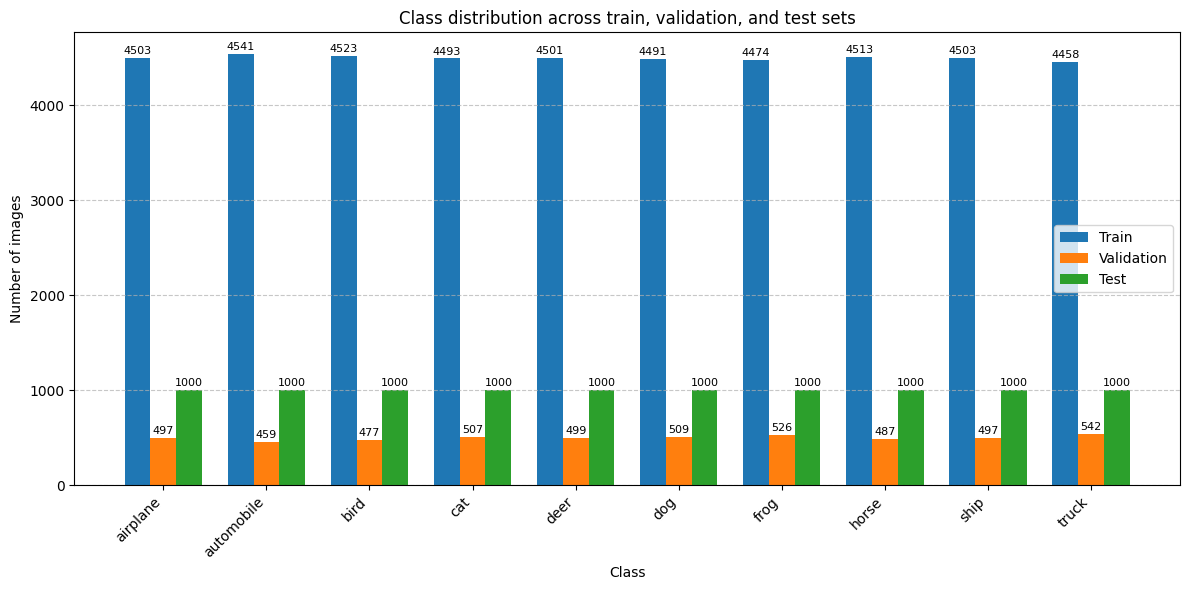

In [7]:
# ===================== PLOT CLASS DISTRIBUTION =====================

def plot_class_distribution(train_dataset, val_dataset, test_dataset):
    """Plot class distribution across train, validation, and test sets."""
    label_names = test_dataset.classes
    num_classes = len(label_names)

    train_counts = np.zeros(num_classes, dtype=int)
    val_counts = np.zeros(num_classes, dtype=int)
    test_counts = np.zeros(num_classes, dtype=int)

    # count train labels
    for idx in train_dataset.indices:
        label = train_dataset.dataset.targets[idx]
        train_counts[label] += 1

    # count validation labels
    for idx in val_dataset.indices:
        label = val_dataset.dataset.targets[idx]
        val_counts[label] += 1

    # count test labels
    for label in test_dataset.targets:
        test_counts[label] += 1

    x = np.arange(num_classes)
    bar_width = 0.25

    fig, ax = plt.subplots(figsize=(12, 6))

    bars_train = ax.bar(x - bar_width, train_counts, width=bar_width, label="Train")
    bars_val = ax.bar(x, val_counts, width=bar_width, label="Validation")
    bars_test = ax.bar(x + bar_width, test_counts, width=bar_width, label="Test")

    # add numbers on top of bars
    def add_labels(bars):
        for bar in bars:
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width()/2,
                height + 20,
                str(int(height)),
                ha='center',
                va='bottom',
                fontsize=8
            )

    add_labels(bars_train)
    add_labels(bars_val)
    add_labels(bars_test)

    ax.set_xticks(x)
    ax.set_xticklabels(label_names, rotation=45, ha='right')
    ax.set_ylabel("Number of images")
    ax.set_xlabel("Class")
    ax.set_title("Class distribution across train, validation, and test sets")

    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.legend()
    fig.tight_layout()
    
    return fig

train_dataset, val_dataset, test_dataset = get_train_val_test_data()
fig_dist = plot_class_distribution(train_dataset, val_dataset, test_dataset)
save_figure(fig_dist, "class_distribution_train_val_test.png")
plt.show()

Saved figure: /home/raveco/deep_learning_ass1/outputs/rgb_stats_per_class.png


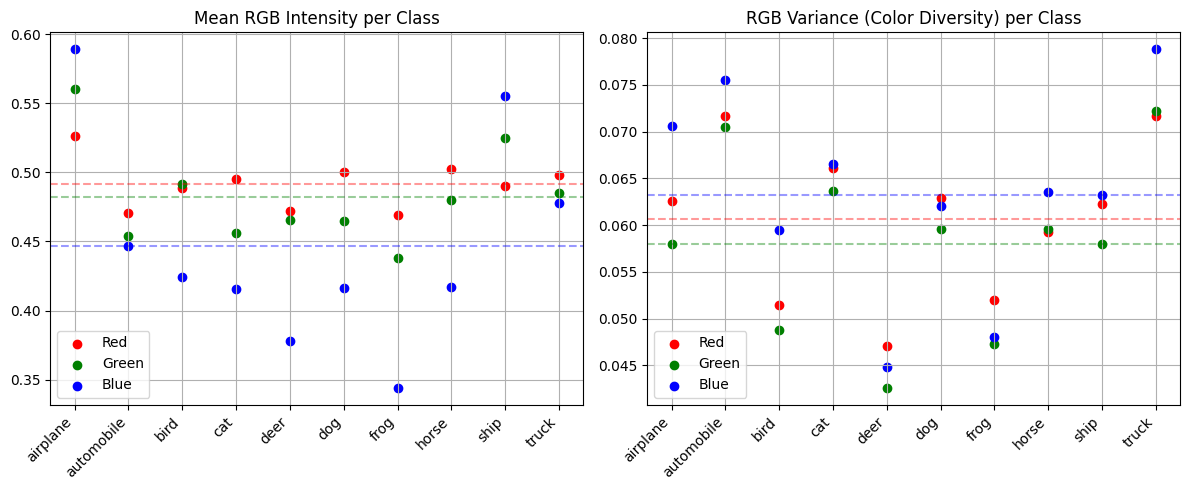

airplane:
  Mean RGB     = [0.52644295 0.5606423  0.58904034]
  Variance RGB = [0.06260979 0.05800503 0.07056758]

automobile:
  Mean RGB     = [0.47054693 0.45370778 0.44658437]
  Variance RGB = [0.0717175  0.07049945 0.07551865]

bird:
  Mean RGB     = [0.4889078  0.49128348 0.42435563]
  Variance RGB = [0.05151309 0.04875354 0.05945219]

cat:
  Mean RGB     = [0.49493685 0.4563362  0.41538334]
  Variance RGB = [0.06606969 0.06365757 0.06654912]

deer:
  Mean RGB     = [0.47221276 0.4652912  0.37814313]
  Variance RGB = [0.04708175 0.04260013 0.04483339]

dog:
  Mean RGB     = [0.5002567  0.46453154 0.41627955]
  Variance RGB = [0.06289983 0.05957094 0.06202723]

frog:
  Mean RGB     = [0.46941644 0.4377875  0.3440341 ]
  Variance RGB = [0.0519831  0.04732096 0.04802757]

horse:
  Mean RGB     = [0.502241   0.47990283 0.4169365 ]
  Variance RGB = [0.05924782 0.05962326 0.06350827]

ship:
  Mean RGB     = [0.48976278 0.5250435  0.55489784]
  Variance RGB = [0.06229077 0.05795768 0.063

In [8]:
# ===================== RGB CLASS ANALYSIS =====================

def compute_class_rgb_stats(dataset):
    """
    Computes per-class RGB mean and variance.

    Args:
        dataset: torch.utils.data.Subset (train/val)

    Returns:
        class_means: (num_classes, 3)
        class_vars: (num_classes, 3)
    """
    num_classes = len(dataset.dataset.classes)

    pixel_sum = torch.zeros(num_classes, 3)
    pixel_sq_sum = torch.zeros(num_classes, 3)
    pixel_count = torch.zeros(num_classes)

    for idx in dataset.indices:
        img, label = dataset.dataset[idx]  # (C,H,W)

        img = img.view(3, -1)  # flatten → (3, pixels)

        pixel_sum[label] += img.sum(dim=1)
        pixel_sq_sum[label] += (img ** 2).sum(dim=1)
        pixel_count[label] += img.shape[1]

    class_means = pixel_sum / pixel_count.unsqueeze(1)
    class_vars = (pixel_sq_sum / pixel_count.unsqueeze(1)) - class_means**2

    return class_means.numpy(), class_vars.numpy()


def plot_rgb_stats(class_means, class_vars, class_names):
    """Plot RGB statistics (mean and variance) per class."""
    x = np.arange(len(class_names))
    mean_R = class_means[:, 0].mean()
    mean_G = class_means[:, 1].mean()
    mean_B = class_means[:, 2].mean()

    var_R = class_vars[:, 0].mean()
    var_G = class_vars[:, 1].mean()
    var_B = class_vars[:, 2].mean()

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # ---- Mean ----
    axes[0].scatter(x, class_means[:, 0], color='r', label="Red")
    axes[0].scatter(x, class_means[:, 1], color='g', label="Green")
    axes[0].scatter(x, class_means[:, 2], color='b', label="Blue")
    axes[0].set_title("Mean RGB Intensity per Class")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(class_names, rotation=45, ha='right')
    axes[0].legend()
    axes[0].grid(True)

    axes[0].axhline(mean_R, color='r', linestyle='--', alpha=0.4)
    axes[0].axhline(mean_G, color='g', linestyle='--', alpha=0.4)
    axes[0].axhline(mean_B, color='b', linestyle='--', alpha=0.4)

    # ---- Variance ----
    axes[1].scatter(x, class_vars[:, 0], color='r', label="Red")
    axes[1].scatter(x, class_vars[:, 1], color='g', label="Green")
    axes[1].scatter(x, class_vars[:, 2], color='b', label="Blue")
    axes[1].set_title("RGB Variance (Color Diversity) per Class")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(class_names, rotation=45, ha='right')
    axes[1].legend()
    axes[1].grid(True)

    axes[1].axhline(var_R, color='r', linestyle='--', alpha=0.4)
    axes[1].axhline(var_G, color='g', linestyle='--', alpha=0.4)
    axes[1].axhline(var_B, color='b', linestyle='--', alpha=0.4)

    fig.tight_layout()
    return fig


# ---- RUN ANALYSIS ----
class_means, class_vars = compute_class_rgb_stats(train_dataset)
fig_rgb_stats = plot_rgb_stats(class_means, class_vars, train_dataset.dataset.classes)
save_figure(fig_rgb_stats, "rgb_stats_per_class.png")
plt.show()

# Optional: print numeric values (useful for report)
for i, cls in enumerate(train_dataset.dataset.classes):
    print(f"{cls}:")
    print(f"  Mean RGB     = {class_means[i]}")
    print(f"  Variance RGB = {class_vars[i]}")
    print()

# =============================================================

Saved figure: /home/raveco/deep_learning_ass1/outputs/pca_with_silhouette_table.png


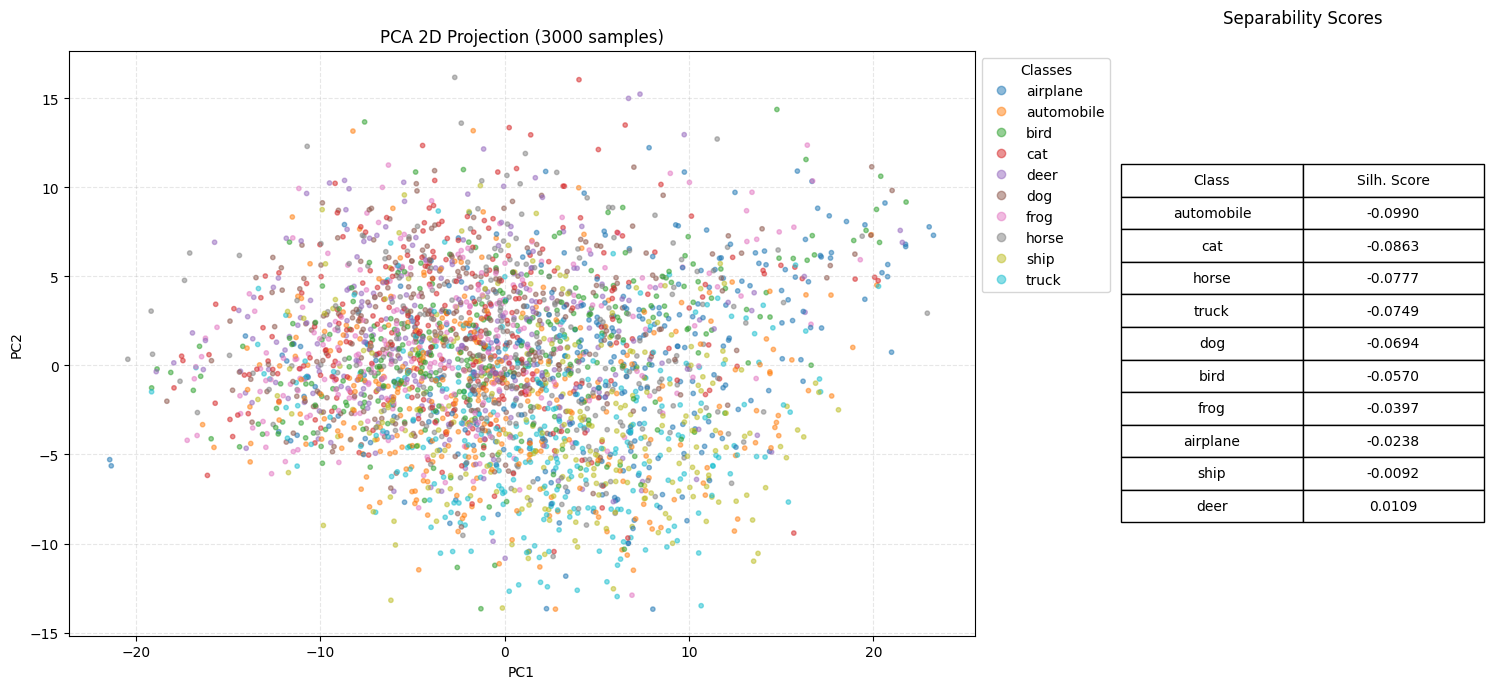

In [9]:
def plot_combined_analysis(dataset, num_samples=3000):
    """
    Computes PCA and Silhouette scores together and plots them side-by-side.
    """
    # 1. Prepare Data
    images, labels = [], []
    indices = dataset.indices[:num_samples]
    for idx in indices:
        img, lbl = dataset.dataset[idx]
        images.append(img.view(-1).numpy())
        labels.append(lbl)
    
    images = np.array(images)
    labels = np.array(labels)
    class_names = dataset.dataset.classes

    # 2. Compute PCA
    pca = PCA(n_components=2)
    projected = pca.fit_transform(images)

    # 3. Compute Silhouette Scores
    sample_scores = silhouette_samples(images, labels)
    class_scores = []
    for i in range(len(class_names)):
        avg_score = np.mean(sample_scores[labels == i])
        class_scores.append([class_names[i], f"{avg_score:.4f}"])
    
    # Sort table by score (lowest to highest) for the plot
    class_scores.sort(key=lambda x: float(x[1]))

    # 4. Plotting
    # Create a figure with extra width for the table
    fig, (ax_plot, ax_table) = plt.subplots(1, 2, figsize=(15, 7), gridspec_kw={'width_ratios': [3, 1]})

    # Scatter Plot
    scatter = ax_plot.scatter(projected[:, 0], projected[:, 1], c=labels, cmap='tab10', alpha=0.5, s=10)
    handles, _ = scatter.legend_elements()
    ax_plot.legend(handles, class_names, title="Classes", loc="upper left", bbox_to_anchor=(1, 1))
    ax_plot.set_title(f"PCA 2D Projection ({num_samples} samples)")
    ax_plot.set_xlabel("PC1")
    ax_plot.set_ylabel("PC2")
    ax_plot.grid(True, linestyle='--', alpha=0.3)

    # Table Plot
    ax_table.axis('off')
    table = ax_table.table(
        cellText=class_scores, 
        colLabels=["Class", "Silh. Score"], 
        loc='center',
        cellLoc='center'
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.8) # Adjust scaling for readability
    ax_table.set_title("Separability Scores", pad=20)

    fig.tight_layout()
    return fig

# Run the combined analysis
fig_combined = plot_combined_analysis(train_dataset, num_samples=3000)
save_figure(fig_combined, "pca_with_silhouette_table.png")
plt.show()

In [10]:
def train(model, optimizer, loss_fn, train_loader, val_loader=None, epochs=10, device="cuda"):
    """
    Train a neural network model and optionally evaluate its performance on validation data.

    Parameters:
        model: The neural network model to be trained.
        optimizer: The optimizer used to update the model parameters.
        loss_fn: The loss function used to compute the training loss.
        train_loader: DataLoader providing the training data in batches.
        val_loader (optional): DataLoader providing the validation data in batches.
        epochs (int): Number of training epochs.
        device (str): Device for computation (e.g., "cuda" or "cpu").
    """
    model.to(device)
    # Initialize history to track both Loss and Accuracy as required for Part 2 plots
    history = {
        "train_loss": [], "val_loss": [], 
        "train_acc": [], "val_acc": []
    }
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()
            
            # Aggregate Loss
            running_loss += loss.item() * inputs.size(0)
            
            # Aggregate Accuracy
            _, predicted = outputs.max(1)
            total_train += labels.size(0)
            correct_train += predicted.eq(labels).sum().item()
        
        train_loss = running_loss / len(train_loader.dataset)
        train_acc = correct_train / total_train
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)

        if val_loader is not None:
            model.eval()
            val_running_loss = 0.0
            correct_val = 0
            total_val = 0
            
            with torch.no_grad():
                for val_inputs, val_labels in val_loader:
                    val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)
                    val_outputs = model(val_inputs)
                    val_loss = loss_fn(val_outputs, val_labels)
                    
                    val_running_loss += val_loss.item() * val_inputs.size(0)
                    _, val_predicted = val_outputs.max(1)
                    total_val += val_labels.size(0)
                    correct_val += val_predicted.eq(val_labels).sum().item()
            
            val_loss = val_running_loss / len(val_loader.dataset)
            val_acc = correct_val / total_val
            history["val_loss"].append(val_loss)
            history["val_acc"].append(val_acc)
            
            print(f"Epoch {epoch+1}/{epochs}: "
                  f"Loss[T: {train_loss:.4f}, V: {val_loss:.4f}] | "
                  f"Acc[T: {100*train_acc:.2f}%, V: {100*val_acc:.2f}%]")
        else:
            print(f"Epoch {epoch+1}/{epochs}: train_loss={train_loss:.4f}, train_acc={100*train_acc:.2f}%")

    return history


def test(model, test_loader, loss_fn, device="cuda"):
    """
    Evaluate the trained model on the test dataset.

    Parameters:
        model: The trained model to evaluate.
        test_loader: DataLoader providing the test data in batches.
        loss_fn: The loss function used to compute the test loss.
        device (str): Device for computation (e.g., "cuda" or "cpu").

    Returns:
        average_loss: Average loss on the test set.
        accuracy: Classification accuracy on the test set.
    """
    model.to(device)
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = loss_fn(outputs, labels)
            
            test_loss += loss.item() * inputs.size(0)
            _, preds = outputs.max(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    average_loss = test_loss / len(test_loader.dataset)
    accuracy = correct / total
    
    return average_loss, accuracy

## Model Definitions

The following cells contain commented-out model architectures that can be uncommented and used as needed.

In [11]:
import torch.nn as nn
import torch.nn.functional as F

class VanillaMLP(nn.Module):
    def __init__(self, input_size=3072, hidden_dims=[512, 256], num_classes=10):
        """
        Initialize the MLP network.

        Parameters:
            input_size (int): The total number of input features (e.g., for a 32x32*3 color image).
            hidden_dims (list of int): A list specifying the number of neurons in each hidden layer.
            num_class (int): The number of output classes for classification.
        """
        super(VanillaMLP, self).__init__()
        layers = []
        
        # Input Layer
        prev_dim = input_size
        
        # Hidden Layers
        for dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, dim))
            layers.append(nn.ReLU()) # Standard choice for vanilla MLP
            prev_dim = dim
            
        # Output Layer
        layers.append(nn.Linear(prev_dim, num_classes))
        
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        # Flatten the image: (Batch, 3, 32, 32) -> (Batch, 3072)
        x = x.view(x.size(0), -1)
        return self.model(x)

In [ ]:
# %%
# Define experiments to run
experiments = [
    # --- BASELINE ---
    {"name": "Exp1_Base", "hidden_dims": [512, 256], "lr": 0.001, "batch_size": 64},

    # --- ARCHITECTURE VARIATIONS ---
    # Change: Depth (More layers)
    {"name": "Exp2_Deep", "hidden_dims": [1024, 512, 256, 128], "lr": 0.001, "batch_size": 64},
    # Change: Width (More units per layer)
    {"name": "Exp7_Wide", "hidden_dims": [1024, 1024], "lr": 0.001, "batch_size": 64},

    # --- LEARNING RATE VARIATIONS ---
    # Change: Smaller LR
    {"name": "Exp3_Small_LR", "hidden_dims": [512, 256], "lr": 0.0001, "batch_size": 64},
    # Change: Larger LR
    {"name": "Exp4_Large_LR", "hidden_dims": [512, 256], "lr": 0.01, "batch_size": 64},

    # --- BATCH SIZE VARIATIONS ---
    # Change: Mini-batch 32
    {"name": "Exp5_Batch32", "hidden_dims": [512, 256], "lr": 0.001, "batch_size": 32},
    # Change: Mini-batch 16
    {"name": "Exp6_Batch16", "hidden_dims": [512, 256], "lr": 0.001, "batch_size": 16}
]

results_log = {}

for exp in experiments:
    print(f"\n--- Running Experiment: {exp['name']} ---")
    
    # Update DataLoaders for specific batch size
    train_loader = DataLoader(train_dataset, batch_size=exp['batch_size'], shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=exp['batch_size'], shuffle=False)
    
    # Initialize model, optimizer, and loss
    model = VanillaMLP(hidden_dims=exp['hidden_dims']).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=exp['lr'])
    loss_fn = nn.CrossEntropyLoss()
    
    # Train using your provided train function
    history = train(
        model=model, 
        optimizer=optimizer, 
        loss_fn=loss_fn, 
        train_loader=train_loader, 
        val_loader=val_loader, 
        epochs=15, 
        device=device
    )
    
    # Log results
    results_log[exp['name']] = {
        "history": history,
        "config": exp
    }

# %% [markdown]
# ### Justification for Hyperparameter Choice (for your report)
# After running the cell above, look at the `val_loss`. 
# 1. **Learning Rate:** If Exp1 converges faster than Exp3, but Exp3 has a smoother validation loss curve, Exp3 might be better to avoid overfitting.
# 2. **Model Depth:** If Exp2 (Deep) has lower training loss but higher validation loss than Exp1, it indicates the deeper model is simply memorizing the training set (overfitting) rather than learning features.
# 3. **Batch Size:** Larger batch sizes (Exp3) often provide more stable gradients but might require more epochs to reach the same accuracy.


--- Running Experiment: Exp1_Base ---


Epoch 1/15: Loss[T: 1.8568, V: 1.7280] | Acc[T: 32.19%, V: 38.76%]
Epoch 2/15: Loss[T: 1.6756, V: 1.6117] | Acc[T: 39.76%, V: 42.94%]
Epoch 3/15: Loss[T: 1.5946, V: 1.5460] | Acc[T: 42.80%, V: 45.90%]
Epoch 4/15: Loss[T: 1.5328, V: 1.5265] | Acc[T: 45.39%, V: 46.04%]
Epoch 5/15: Loss[T: 1.4965, V: 1.5259] | Acc[T: 46.45%, V: 45.70%]
Epoch 6/15: Loss[T: 1.4564, V: 1.5097] | Acc[T: 47.97%, V: 46.00%]
Epoch 7/15: Loss[T: 1.4318, V: 1.4679] | Acc[T: 48.94%, V: 47.96%]
Epoch 8/15: Loss[T: 1.4066, V: 1.4480] | Acc[T: 49.49%, V: 48.92%]
Epoch 9/15: Loss[T: 1.3793, V: 1.4836] | Acc[T: 50.78%, V: 47.40%]
Epoch 10/15: Loss[T: 1.3515, V: 1.4822] | Acc[T: 51.77%, V: 47.74%]
Epoch 11/15: Loss[T: 1.3332, V: 1.4160] | Acc[T: 52.27%, V: 49.20%]
Epoch 12/15: Loss[T: 1.3112, V: 1.4639] | Acc[T: 52.98%, V: 48.46%]
Epoch 13/15: Loss[T: 1.2883, V: 1.4516] | Acc[T: 53.93%, V: 49.54%]


In [ ]:
class ImprovedMLP(nn.Module):
    def __init__(self, input_size=3*32*32, num_class=10, dropout_p=0.15, use_batchnorm=True):
        """
        Initialize the improved MLP network.

        Parameters:
            input_size (int): Total number of input features (e.g., for a 32x32 color image).
            num_class (int): Number of output classes for classification.
            dropout_p (float): Dropout probability; apply dropout only if this value is > 0.
            use_batchnorm (bool): Whether to use Batch Normalization between layers.
        """
        super(ImprovedMLP, self).__init__()
        
        # Define a sequence of fully connected layers.
        # Add activation functions (e.g., GELU or ReLU) between the layers.
        # If use_batchnorm is True, include Batch Normalization layers after the corresponding linear layers.
        # Only add or activate dropout layers if dropout_p is greater than 0.
        # Ensure the final layer produces 'num_class' outputs.
        pass
        
    def forward(self, x):
        # Flatten the input tensor.
        # Pass the data sequentially through the defined layers.
        # Apply activation functions, and conditionally apply dropout (only if dropout_p > 0).
        # Return the final output logits.
        pass

: 

## End of Notebook

All data analysis and visualization cells have been executed. 

- **Inline plots**: All plots are displayed inline in the notebook using `%matplotlib inline`.
- **Saved outputs**: All plots are also saved to the `outputs/` folder with descriptive filenames.
- **Training & testing**: The `train()` and `test()` functions are ready to use with your model definitions.
- **Model templates**: Uncomment and implement the `VanillaMLP` and `ImprovedMLP` classes as needed.